# Statistical Analysis

In [25]:
import pandas as pd
import numpy as np
import ast
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [26]:
initial_df = pd.read_parquet("../data/processed/anime_data_2.parquet")
initial_df

df = initial_df.head(5278)
df.info()

<class 'pandas.DataFrame'>
Index: 5278 entries, 0 to 5307
Data columns (total 86 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   mal_id                  5278 non-null   int64  
 1   title                   5278 non-null   str    
 2   producers               5278 non-null   object 
 3   genres                  5278 non-null   object 
 4   studios                 5278 non-null   object 
 5   demographics            5278 non-null   object 
 6   themes                  5278 non-null   object 
 7   rating                  5278 non-null   str    
 8   members                 5278 non-null   int64  
 9   thumbnail               5278 non-null   bool   
 10  prequel_score           1364 non-null   float64
 11  prequel_members         1376 non-null   float64
 12  prequel_type            1376 non-null   str    
 13  cohort                  5278 non-null   str    
 14  drop_rate               5278 non-null   float64
 15  wc_

## Anime Adaptation Relations (Linear Regression)

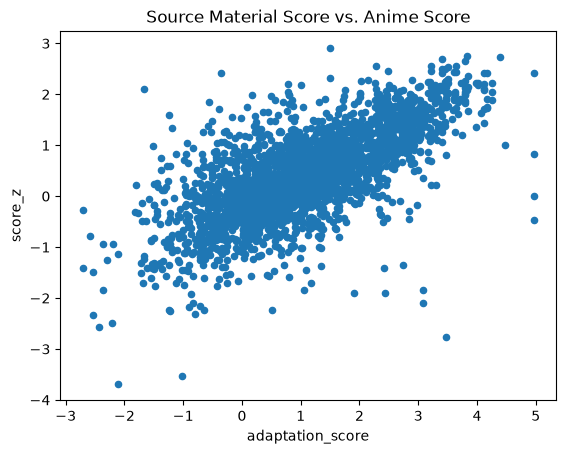

In [27]:
adaptation_df = df[~df['adaptation_score'].isna()]
adaptation_df.plot.scatter(x='adaptation_score', y='score_z', title='Source Material Score vs. Anime Score')
plt.show()

We will now perform a Linear Regression:

Correct R^2 Score: 0.4800582596424984


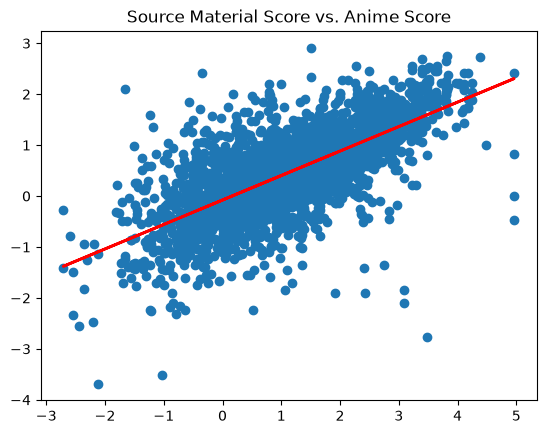

In [28]:
X = adaptation_df[['adaptation_score']]
y = adaptation_df[['score_z']]

model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)  
print(f"Correct R^2 Score: {r2}")

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red', linewidth=2)
plt.title('Source Material Score vs. Anime Score')
plt.show()

We perform the same analysis on member count vs WC score:

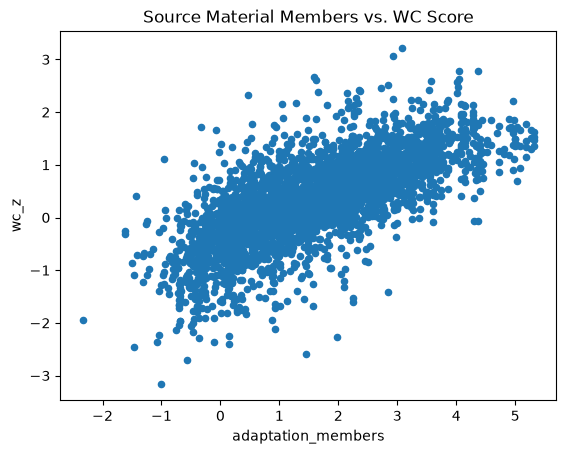

In [29]:
adaptation_df = df[~df['adaptation_members'].isna()]
adaptation_df.plot.scatter(x='adaptation_members', y='wc_z', title='Source Material Members vs. WC Score')
plt.show()

Correct R^2 Score: 0.5126149991110968


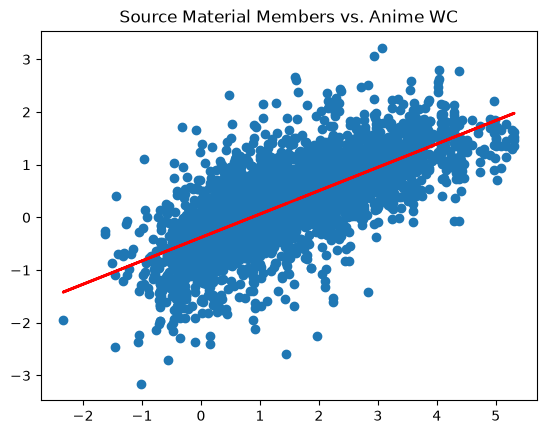

In [30]:
X = adaptation_df[['adaptation_members']]
y = adaptation_df[['wc_z']]

model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)  
print(f"Correct R^2 Score: {r2}")

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red', linewidth=2)
plt.title('Source Material Members vs. Anime WC')
plt.show()

## Genre, Theme, Demographic vs. Score Z-score (Multiple Regression)

In [31]:
genre_averages = df.explode('genres').groupby('genres')['score_z'].mean().sort_values()
genre_counts = df['genres'].explode().value_counts()
print(genre_counts)
genre_averages

genres
Comedy           2109
Action           1461
Fantasy          1273
Adventure        1180
Sci-Fi            979
Romance           942
Drama             909
Supernatural      509
Mystery           374
Ecchi             331
Slice of Life     305
Sports            275
Suspense          186
Horror            155
Gourmet            76
Girls Love         46
Boys Love          37
Avant Garde        35
Erotica            11
Name: count, dtype: int64


genres
Erotica         -0.761626
Ecchi           -0.342079
Avant Garde     -0.229368
Horror          -0.163462
Comedy          -0.116973
Fantasy         -0.051838
Sci-Fi          -0.024197
Adventure        0.039700
Girls Love       0.100371
Gourmet          0.104083
Action           0.104783
Slice of Life    0.114877
Boys Love        0.137757
Romance          0.206333
Supernatural     0.237214
Sports           0.271354
Mystery          0.352253
Drama            0.429598
Suspense         0.470675
Name: score_z, dtype: float64

In [32]:
genre_cols = [c for c in df.columns if c.startswith('genre_')]

# drop genres that are too rare to estimate reliably (mirrors your bucket_rare logic)
min_count = 50
valid_genres = [c for c in genre_cols if df[c].sum() >= min_count]
dropped = set(genre_cols) - set(valid_genres)
if dropped:
    print(f"Dropping {len(dropped)} rare genres from regression: {sorted(dropped)}")

X = df[valid_genres].copy()
X = sm.add_constant(X)  # intercept = baseline z-score for "no genres present" (rarely meaningful alone, but needed for coefficients to be interpretable as offsets)
y = df['score_z']

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

results = pd.DataFrame({
    'genre': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("genre != 'const'")

# FDR correction across all genre coefficients (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results['pval_fdr'] = multipletests(results['pval'], method='fdr_bh')[1]
results['significant'] = results['pval_fdr'] < 0.05

results = results.sort_values('coef', ascending=False)
results

                            OLS Regression Results                            
Dep. Variable:                score_z   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     36.77
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          1.51e-108
Time:                        09:41:10   Log-Likelihood:                -7084.0
No. Observations:                5278   AIC:                         1.420e+04
Df Residuals:                    5261   BIC:                         1.431e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.3183    

,genre,coef,pval,ci_low,ci_high,pval_fdr,significant
genre_Sports,genre_Sports,0.497301,5.167834e-16,0.377434,0.617169,2.067134e-15,True
genre_Drama,genre_Drama,0.471044,2.455069e-37,0.399286,0.542803,3.928111e-36,True
genre_Suspense,genre_Suspense,0.407380,5.241782e-08,0.260864,0.553896,8.886567e-08,True
genre_Slice_of_Life,genre_Slice_of_Life,0.378837,3.424652e-10,0.260770,0.496905,9.132405e-10,True
genre_Romance,genre_Romance,0.334687,1.291814e-20,0.264497,0.404877,1.033452e-19,True
genre_Mystery,genre_Mystery,0.310334,5.704751e-09,0.206067,0.414601,1.303943e-08,True
genre_Supernatural,genre_Supernatural,0.267704,1.498673e-08,0.175155,0.360253,2.997346e-08,True
genre_Action,genre_Action,0.259888,2.177213e-16,0.198047,0.321729,1.161180e-15,True
genre_Gourmet,genre_Gourmet,0.246850,2.235629e-02,0.035059,0.458641,2.980839e-02,True
genre_Adventure,genre_Adventure,0.114035,6.755314e-04,0.048309,0.179760,9.825911e-04,True


In [33]:
theme_cols = [c for c in df.columns if c.startswith('theme_')]

# drop genres that are too rare to estimate reliably (mirrors your bucket_rare logic)
min_count = 50
valid_themes = [c for c in theme_cols if df[c].sum() >= min_count]
dropped = set(theme_cols) - set(valid_themes)
if dropped:
    print(f"Dropping {len(dropped)} rare themes from regression: {sorted(dropped)}")

X = df[valid_themes].copy()
X = sm.add_constant(X)  # intercept = baseline z-score for "no genres present" (rarely meaningful alone, but needed for coefficients to be interpretable as offsets)
y = df['score_z']

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

results = pd.DataFrame({
    'theme': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("theme != 'const'")

# FDR correction across all genre coefficients (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results['pval_fdr'] = multipletests(results['pval'], method='fdr_bh')[1]
results['significant'] = results['pval_fdr'] < 0.05

results = results.sort_values('coef', ascending=False)
results

                            OLS Regression Results                            
Dep. Variable:                score_z   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     19.96
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          5.92e-122
Time:                        09:41:11   Log-Likelihood:                -7015.8
No. Observations:                5278   AIC:                         1.411e+04
Df Residuals:                    5240   BIC:                         1.436e+04
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.28

,theme,coef,pval,ci_low,ci_high,pval_fdr,significant
theme_Iyashikei,theme_Iyashikei,0.873285,8.329037e-17,0.668365,1.078205,1.027248e-15,True
theme_Love_Polygon,theme_Love_Polygon,0.583995,1.666567e-07,0.365518,0.802473,6.851443e-07,True
theme_Adult_Cast,theme_Adult_Cast,0.559790,1.572695e-22,0.447937,0.671643,5.818971e-21,True
theme_Gag_Humor,theme_Gag_Humor,0.540854,4.868021e-11,0.379930,0.701779,4.502920e-10,True
theme_Organized_Crime,theme_Organized_Crime,0.513453,8.502243e-05,0.257512,0.769393,1.966144e-04,True
theme_Urban_Fantasy,theme_Urban_Fantasy,0.466001,1.120256e-07,0.294068,0.637934,5.921352e-07,True
theme_Performing_Arts,theme_Performing_Arts,0.452940,1.995856e-04,0.214383,0.691497,4.102593e-04,True
theme_Otaku_Culture,theme_Otaku_Culture,0.445481,1.753514e-04,0.212892,0.678070,3.816471e-04,True
theme_Team_Sports,theme_Team_Sports,0.416801,1.376341e-06,0.247769,0.585833,5.085694e-06,True
theme_Military,theme_Military,0.388410,7.171611e-09,0.257045,0.519775,4.422494e-08,True


In [34]:
demo_cols = [c for c in df.columns if c.startswith('demo_')]

# drop genres that are too rare to estimate reliably (mirrors your bucket_rare logic)
min_count = 50
valid_demos = [c for c in demo_cols if df[c].sum() >= min_count]
dropped = set(demo_cols) - set(valid_demos)
if dropped:
    print(f"Dropping {len(dropped)} rare demographics from regression: {sorted(dropped)}")

X = df[valid_demos].copy()
X = sm.add_constant(X)  # intercept = baseline z-score for "no genres present" (rarely meaningful alone, but needed for coefficients to be interpretable as offsets)
y = df['score_z']

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

results = pd.DataFrame({
    'demographic': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("demographic != 'const'")

# FDR correction across all genre coefficients (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results['pval_fdr'] = multipletests(results['pval'], method='fdr_bh')[1]
results['significant'] = results['pval_fdr'] < 0.05

results = results.sort_values('coef', ascending=False)
results

                            OLS Regression Results                            
Dep. Variable:                score_z   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     148.6
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          4.80e-148
Time:                        09:41:11   Log-Likelihood:                -7015.7
No. Observations:                5278   AIC:                         1.404e+04
Df Residuals:                    5272   BIC:                         1.408e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.1491      0.016     -9.230   

,demographic,coef,pval,ci_low,ci_high,pval_fdr,significant
demo_Shounen,demo_Shounen,0.673640,1.657037e-81,0.605775,0.741506,8.285187e-81,True
demo_Shoujo,demo_Shoujo,0.591330,2.955963e-20,0.466117,0.716542,3.694953e-20,True
demo_Seinen,demo_Seinen,0.509098,2.286081e-30,0.422497,0.595699,5.715203e-30,True
demo_Josei,demo_Josei,0.377048,3.249502e-04,0.171547,0.582548,3.249502e-04,True
demo_Kids,demo_Kids,-0.554143,3.761880e-30,-0.648768,-0.459517,6.269800e-30,True


## Genre, Theme, Demographic vs. WC Z-score (Multiple Regression)

In [35]:
genre_cols = [c for c in df.columns if c.startswith('genre_')]

# drop genres that are too rare to estimate reliably (mirrors your bucket_rare logic)
min_count = 50
valid_genres = [c for c in genre_cols if df[c].sum() >= min_count]
dropped = set(genre_cols) - set(valid_genres)
if dropped:
    print(f"Dropping {len(dropped)} rare genres from regression: {sorted(dropped)}")

X = df[valid_genres].copy()
X = sm.add_constant(X)  # intercept = baseline z-score for "no genres present" (rarely meaningful alone, but needed for coefficients to be interpretable as offsets)
y = df['wc_z']

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

results = pd.DataFrame({
    'genre': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("genre != 'const'")

# FDR correction across all genre coefficients (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results['pval_fdr'] = multipletests(results['pval'], method='fdr_bh')[1]
results['significant'] = results['pval_fdr'] < 0.05

results = results.sort_values('coef', ascending=False)
results

                            OLS Regression Results                            
Dep. Variable:                   wc_z   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                     85.91
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          1.86e-250
Time:                        09:41:11   Log-Likelihood:                -6751.1
No. Observations:                5278   AIC:                         1.354e+04
Df Residuals:                    5261   BIC:                         1.365e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.5637    

,genre,coef,pval,ci_low,ci_high,pval_fdr,significant
genre_Suspense,genre_Suspense,0.730018,4.172646e-25,0.592457,0.867578,1.669059e-24,True
genre_Romance,genre_Romance,0.707476,1.766956e-94,0.641576,0.773376,2.827129e-93,True
genre_Sports,genre_Sports,0.451771,4.287110e-15,0.339229,0.564312,9.799109e-15,True
genre_Action,genre_Action,0.451516,2.189596e-51,0.393455,0.509578,1.751677e-50,True
genre_Drama,genre_Drama,0.379779,4.412057e-28,0.312407,0.447151,2.353097e-27,True
genre_Supernatural,genre_Supernatural,0.359763,5.910045e-16,0.272871,0.446656,1.576012e-15,True
genre_Ecchi,genre_Ecchi,0.353825,8.119123e-12,0.252593,0.455058,1.623825e-11,True
genre_Other,genre_Other,0.332314,3.671726e-05,0.174601,0.490026,5.802776e-05,True
genre_Fantasy,genre_Fantasy,0.283295,7.053651e-19,0.220948,0.345642,2.257168e-18,True
genre_Gourmet,genre_Gourmet,0.260637,1.020874e-02,0.061791,0.459483,1.256461e-02,True


In [36]:
theme_cols = [c for c in df.columns if c.startswith('theme_')]

# drop genres that are too rare to estimate reliably (mirrors your bucket_rare logic)
min_count = 50
valid_themes = [c for c in theme_cols if df[c].sum() >= min_count]
dropped = set(theme_cols) - set(valid_themes)
if dropped:
    print(f"Dropping {len(dropped)} rare themes from regression: {sorted(dropped)}")

X = df[valid_themes].copy()
X = sm.add_constant(X)  # intercept = baseline z-score for "no genres present" (rarely meaningful alone, but needed for coefficients to be interpretable as offsets)
y = df['wc_z']

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

results = pd.DataFrame({
    'theme': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("theme != 'const'")

# FDR correction across all genre coefficients (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results['pval_fdr'] = multipletests(results['pval'], method='fdr_bh')[1]
results['significant'] = results['pval_fdr'] < 0.05

results = results.sort_values('coef', ascending=False)
results

                            OLS Regression Results                            
Dep. Variable:                   wc_z   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     36.60
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          1.26e-229
Time:                        09:41:11   Log-Likelihood:                -6757.1
No. Observations:                5278   AIC:                         1.359e+04
Df Residuals:                    5240   BIC:                         1.384e+04
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.27

,theme,coef,pval,ci_low,ci_high,pval_fdr,significant
theme_Love_Polygon,theme_Love_Polygon,0.793728,8.671983e-14,0.585699,1.001757,4.583762e-13,True
theme_Gore,theme_Gore,0.721548,1.116381e-15,0.545575,0.897522,8.261217e-15,True
theme_Isekai,theme_Isekai,0.686011,6.525826e-28,0.563918,0.808104,1.207278e-26,True
theme_Psychological,theme_Psychological,0.583154,1.952246e-15,0.439690,0.726619,1.203885e-14,True
theme_Urban_Fantasy,theme_Urban_Fantasy,0.582544,3.415790e-12,0.418833,0.746254,1.404269e-11,True
theme_Harem,theme_Harem,0.523316,5.652579e-20,0.411656,0.634975,6.971514e-19,True
theme_Otaku_Culture,theme_Otaku_Culture,0.520005,4.260773e-06,0.298540,0.741470,1.126062e-05,True
theme_Organized_Crime,theme_Organized_Crime,0.473648,1.404425e-04,0.229948,0.717348,3.056690e-04,True
theme_Adult_Cast,theme_Adult_Cast,0.443458,4.066194e-16,0.336954,0.549962,3.761230e-15,True
theme_School,theme_School,0.442083,3.983829e-40,0.377271,0.506895,1.474017e-38,True


In [37]:
demo_cols = [c for c in df.columns if c.startswith('demo_')]

# drop genres that are too rare to estimate reliably (mirrors your bucket_rare logic)
min_count = 50
valid_demos = [c for c in demo_cols if df[c].sum() >= min_count]
dropped = set(demo_cols) - set(valid_demos)
if dropped:
    print(f"Dropping {len(dropped)} rare demographics from regression: {sorted(dropped)}")

X = df[valid_demos].copy()
X = sm.add_constant(X)  # intercept = baseline z-score for "no genres present" (rarely meaningful alone, but needed for coefficients to be interpretable as offsets)
y = df['wc_z']

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

results = pd.DataFrame({
    'demographic': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("demographic != 'const'")

# FDR correction across all genre coefficients (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results['pval_fdr'] = multipletests(results['pval'], method='fdr_bh')[1]
results['significant'] = results['pval_fdr'] < 0.05

results = results.sort_values('coef', ascending=False)
results

                            OLS Regression Results                            
Dep. Variable:                   wc_z   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     195.0
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          3.43e-191
Time:                        09:41:11   Log-Likelihood:                -6915.9
No. Observations:                5278   AIC:                         1.384e+04
Df Residuals:                    5272   BIC:                         1.388e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0839      0.016     -5.291   

,demographic,coef,pval,ci_low,ci_high,pval_fdr,significant
demo_Shounen,demo_Shounen,0.600343,5.965035e-68,0.533749,0.666937,1.491259e-67,True
demo_Shoujo,demo_Shoujo,0.454979,4.450981e-13,0.332113,0.577846,5.563726e-13,True
demo_Seinen,demo_Seinen,0.378712,3.178957e-18,0.293733,0.463691,5.298262e-18,True
demo_Josei,demo_Josei,0.219153,3.317102e-02,0.017502,0.420803,3.317102e-02,True
demo_Kids,demo_Kids,-0.981998,7.387477e-92,-1.074851,-0.889146,3.693738e-91,True


## Genre, Theme, Demographic vs. Drop Rate Z-score (Multiple Regression)

In [38]:
genre_cols = [c for c in df.columns if c.startswith('genre_')]

# drop genres that are too rare to estimate reliably (mirrors your bucket_rare logic)
min_count = 50
valid_genres = [c for c in genre_cols if df[c].sum() >= min_count]
dropped = set(genre_cols) - set(valid_genres)
if dropped:
    print(f"Dropping {len(dropped)} rare genres from regression: {sorted(dropped)}")

X = df[valid_genres].copy()
X = sm.add_constant(X)  # intercept = baseline z-score for "no genres present" (rarely meaningful alone, but needed for coefficients to be interpretable as offsets)
y = df['drop_rate_z']

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

results = pd.DataFrame({
    'genre': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("genre != 'const'")

# FDR correction across all genre coefficients (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results['pval_fdr'] = multipletests(results['pval'], method='fdr_bh')[1]
results['significant'] = results['pval_fdr'] < 0.05

results = results.sort_values('coef', ascending=False)
results

                            OLS Regression Results                            
Dep. Variable:            drop_rate_z   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     35.80
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          1.38e-105
Time:                        09:41:11   Log-Likelihood:                -7091.0
No. Observations:                5278   AIC:                         1.422e+04
Df Residuals:                    5261   BIC:                         1.433e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.4069    

,genre,coef,pval,ci_low,ci_high,pval_fdr,significant
genre_Comedy,genre_Comedy,-0.004204,8.903774e-01,-0.063993,0.055586,8.903774e-01,False
genre_Sci-Fi,genre_Sci-Fi,-0.055329,1.122607e-01,-0.123618,0.012959,1.282980e-01,False
genre_Horror,genre_Horror,-0.056951,4.867745e-01,-0.217481,0.103578,5.192261e-01,False
genre_Fantasy,genre_Fantasy,-0.083904,1.340379e-02,-0.150398,-0.017410,1.949643e-02,True
genre_Mystery,genre_Mystery,-0.125864,1.814716e-02,-0.230269,-0.021459,2.419621e-02,True
genre_Adventure,genre_Adventure,-0.138844,3.591768e-05,-0.204656,-0.073031,7.183537e-05,True
genre_Ecchi,genre_Ecchi,-0.225034,4.452416e-05,-0.333001,-0.117068,7.915406e-05,True
genre_Supernatural,genre_Supernatural,-0.226972,1.618883e-06,-0.319644,-0.134300,5.168440e-06,True
genre_Gourmet,genre_Gourmet,-0.235158,2.976353e-02,-0.447230,-0.023085,3.663204e-02,True
genre_Suspense,genre_Suspense,-0.242714,1.189060e-03,-0.389425,-0.096004,1.902496e-03,True


In [39]:
theme_cols = [c for c in df.columns if c.startswith('theme_')]

# drop genres that are too rare to estimate reliably (mirrors your bucket_rare logic)
min_count = 50
valid_themes = [c for c in theme_cols if df[c].sum() >= min_count]
dropped = set(theme_cols) - set(valid_themes)
if dropped:
    print(f"Dropping {len(dropped)} rare themes from regression: {sorted(dropped)}")

X = df[valid_themes].copy()
X = sm.add_constant(X)  # intercept = baseline z-score for "no genres present" (rarely meaningful alone, but needed for coefficients to be interpretable as offsets)
y = df['drop_rate_z']

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

results = pd.DataFrame({
    'theme': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("theme != 'const'")

# FDR correction across all genre coefficients (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results['pval_fdr'] = multipletests(results['pval'], method='fdr_bh')[1]
results['significant'] = results['pval_fdr'] < 0.05

results = results.sort_values('coef', ascending=False)
results

                            OLS Regression Results                            
Dep. Variable:            drop_rate_z   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     16.94
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          1.32e-101
Time:                        09:41:11   Log-Likelihood:                -7065.5
No. Observations:                5278   AIC:                         1.421e+04
Df Residuals:                    5240   BIC:                         1.446e+04
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.27

,theme,coef,pval,ci_low,ci_high,pval_fdr,significant
theme_Pets,theme_Pets,0.314875,1.194851e-02,0.069388,0.560362,2.210474e-02,True
theme_Parody,theme_Parody,0.286343,3.271670e-05,0.151315,0.421371,1.194818e-04,True
theme_Music,theme_Music,0.150215,5.258280e-02,-0.001677,0.302108,7.482936e-02,False
theme_Anthropomorphic,theme_Anthropomorphic,0.148119,5.489085e-02,-0.003105,0.299342,7.522080e-02,False
theme_Samurai,theme_Samurai,0.146583,1.772209e-01,-0.066351,0.359518,2.049116e-01,False
theme_Workplace,theme_Workplace,0.104018,2.477932e-01,-0.072404,0.280441,2.759304e-01,False
theme_Strategy_Game,theme_Strategy_Game,0.056732,4.415555e-01,-0.087778,0.201242,4.667872e-01,False
theme_Detective,theme_Detective,0.019065,8.601560e-01,-0.193069,0.231198,8.840492e-01,False
theme_Racing,theme_Racing,-0.001916,9.860336e-01,-0.216479,0.212647,9.860336e-01,False
theme_Mecha,theme_Mecha,-0.078355,1.275309e-01,-0.179137,0.022428,1.572882e-01,False


In [40]:
demo_cols = [c for c in df.columns if c.startswith('demo_')]

# drop genres that are too rare to estimate reliably (mirrors your bucket_rare logic)
min_count = 50
valid_demos = [c for c in demo_cols if df[c].sum() >= min_count]
dropped = set(demo_cols) - set(valid_demos)
if dropped:
    print(f"Dropping {len(dropped)} rare demographics from regression: {sorted(dropped)}")

X = df[valid_demos].copy()
X = sm.add_constant(X)  # intercept = baseline z-score for "no genres present" (rarely meaningful alone, but needed for coefficients to be interpretable as offsets)
y = df['drop_rate_z']

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

results = pd.DataFrame({
    'demographic': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("demographic != 'const'")

# FDR correction across all genre coefficients (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results['pval_fdr'] = multipletests(results['pval'], method='fdr_bh')[1]
results['significant'] = results['pval_fdr'] < 0.05

results = results.sort_values('coef', ascending=False)
results

                            OLS Regression Results                            
Dep. Variable:            drop_rate_z   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     125.8
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          3.25e-126
Time:                        09:41:11   Log-Likelihood:                -7066.3
No. Observations:                5278   AIC:                         1.414e+04
Df Residuals:                    5272   BIC:                         1.418e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0450      0.016      2.757   

,demographic,coef,pval,ci_low,ci_high,pval_fdr,significant
demo_Kids,demo_Kids,0.902755,2.844919e-74,0.807220,0.998291,1.422459e-73,True
demo_Seinen,demo_Seinen,-0.269466,1.628131e-09,-0.356900,-0.182031,2.713551e-09,True
demo_Josei,demo_Josei,-0.283950,7.319633e-03,-0.491427,-0.076472,7.319633e-03,True
demo_Shoujo,demo_Shoujo,-0.320679,6.804113e-07,-0.447096,-0.194262,8.505141e-07,True
demo_Shounen,demo_Shounen,-0.421860,4.140472e-33,-0.490378,-0.353342,1.035118e-32,True


## Rating vs. Score (Anova + Tukey post-hoc, Multiple Regression)

In [41]:
# one-way ANOVA
groups = [df.loc[df['rating'] == r, 'score_z'].dropna() for r in df['rating'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F={f_stat:.3f}, p={p_val:.4f}")

# Tukey post-hoc
tukey = pairwise_tukeyhsd(endog=df['score_z'], groups=df['rating'], alpha=0.05)
print(tukey)

F=110.832, p=0.0000
                        Multiple Comparison of Means - Tukey HSD, FWER=0.05                         
            group1                         group2             meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------
                  G - All Ages                  PG - Children  -0.1087 0.3114 -0.2639  0.0465  False
                  G - All Ages      PG-13 - Teens 13 or older   0.4522    0.0  0.3492  0.5552   True
                  G - All Ages R - 17+ (violence & profanity)   0.8483    0.0  0.7098  0.9868   True
                  G - All Ages               R+ - Mild Nudity   0.0713  0.804 -0.1048  0.2474  False
                 PG - Children      PG-13 - Teens 13 or older   0.5609    0.0  0.4282  0.6935   True
                 PG - Children R - 17+ (violence & profanity)    0.957    0.0  0.7953  1.1187   True
                 PG - Children               R+ - Mild Nudity     0.18 

We want to also find the partial effects of ratings and sequels taking into account genres, themes, and demographics since they are likely related (e.g. demographics and age ratings definitely correlate). By "partial effects," I mean that if we keep everything else constant, what effect does it have on the score z-score?

In [48]:
rating_dummies = pd.get_dummies(df['rating'], prefix='rating', drop_first=True)
X = pd.concat([df[valid_genres], df[valid_themes], df[valid_demos], rating_dummies], axis=1)
X = X.astype(float)
X = sm.add_constant(X)

model = sm.OLS(df['score_z'], X, missing='drop').fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                score_z   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     36.56
Date:                Thu, 27 Aug 2026   Prob (F-statistic):               0.00
Time:                        10:06:51   Log-Likelihood:                -6485.5
No. Observations:                5278   AIC:                         1.310e+04
Df Residuals:                    5215   BIC:                         1.351e+04
Df Model:                          62                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [49]:
results = pd.DataFrame({
    'feature': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("feature != 'const'")

# FDR correction across all genre coefficients (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results['pval_fdr'] = multipletests(results['pval'], method='fdr_bh')[1]
results['significant'] = results['pval_fdr'] < 0.05

results = results.sort_values('coef', ascending=False)
print(results.loc[results['significant']==True, 'coef'].head(10))
print(results.loc[results['significant']==True, 'coef'].tail(10))

theme_Iyashikei                          0.812328
demo_Shounen                             0.626046
theme_Gag_Humor                          0.501320
theme_Otaku_Culture                      0.464740
theme_Mahou_Shoujo                       0.450646
theme_Adult_Cast                         0.431548
genre_Drama                              0.413630
demo_Shoujo                              0.412410
rating_R - 17+ (violence & profanity)    0.408528
theme_Urban_Fantasy                      0.404059
Name: coef, dtype: float64
theme_Mecha                         0.175605
theme_Anthropomorphic               0.153262
genre_Action                        0.119852
rating_PG-13 - Teens 13 or older    0.106295
theme_Other                         0.097580
theme_Harem                        -0.173020
demo_Kids                          -0.212035
theme_Detective                    -0.280919
genre_Ecchi                        -0.289122
genre_Horror                       -0.394817
Name: coef, dtype: floa

The above shows the top 10 and bottom 10 coefficients for features that yielded statistically significant results $(p < 0.05)$.

## Other Metrics

For the other metrics, we will go straight to partial effects.

In [50]:
rating_dummies = pd.get_dummies(df['rating'], prefix='rating', drop_first=True)
X = pd.concat([df[valid_genres], df[valid_themes], df[valid_demos], rating_dummies], axis=1)
X = X.astype(float)
X = sm.add_constant(X)

model = sm.OLS(df['wc_z'], X, missing='drop').fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   wc_z   R-squared:                       0.415
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                     69.08
Date:                Thu, 27 Aug 2026   Prob (F-statistic):               0.00
Time:                        10:07:18   Log-Likelihood:                -5950.8
No. Observations:                5278   AIC:                         1.203e+04
Df Residuals:                    5215   BIC:                         1.244e+04
Df Model:                          62                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [51]:
results = pd.DataFrame({
    'feature': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("feature != 'const'")

# FDR correction across all genre coefficients (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results['pval_fdr'] = multipletests(results['pval'], method='fdr_bh')[1]
results['significant'] = results['pval_fdr'] < 0.05

results = results.sort_values('coef', ascending=False)
print(results.loc[results['significant']==True, 'coef'].head(10))
print(results.loc[results['significant']==True, 'coef'].tail(10))

rating_R - 17+ (violence & profanity)    0.705655
theme_Otaku_Culture                      0.531319
demo_Shounen                             0.470987
theme_Iyashikei                          0.457154
theme_Isekai                             0.443460
rating_R+ - Mild Nudity                  0.400393
theme_Love_Polygon                       0.394854
rating_PG-13 - Teens 13 or older         0.384596
genre_Romance                            0.384558
theme_School                             0.357889
Name: coef, dtype: float64
genre_Ecchi            0.153337
theme_Mecha            0.148288
theme_Super_Power      0.135938
theme_Other            0.113621
theme_Parody          -0.183591
theme_Samurai         -0.207251
genre_Horror          -0.210689
theme_Martial_Arts    -0.226224
theme_Strategy_Game   -0.324125
demo_Kids             -0.333041
Name: coef, dtype: float64


In [52]:
rating_dummies = pd.get_dummies(df['rating'], prefix='rating', drop_first=True)
X = pd.concat([df[valid_genres], df[valid_themes], df[valid_demos], rating_dummies], axis=1)
X = X.astype(float)
X = sm.add_constant(X)

model = sm.OLS(df['drop_rate_z'], X, missing='drop').fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            drop_rate_z   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     25.88
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          3.16e-253
Time:                        10:07:35   Log-Likelihood:                -6642.5
No. Observations:                5278   AIC:                         1.341e+04
Df Residuals:                    5215   BIC:                         1.382e+04
Df Model:                          62                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [53]:
results = pd.DataFrame({
    'feature': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("feature != 'const'")

# FDR correction across all genre coefficients (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results['pval_fdr'] = multipletests(results['pval'], method='fdr_bh')[1]
results['significant'] = results['pval_fdr'] < 0.05

results = results.sort_values('coef', ascending=False)
print(results.loc[results['significant']==True, 'coef'].head(10))
print(results.loc[results['significant']==True, 'coef'].tail(10))

demo_Kids              0.432721
theme_Samurai          0.253716
theme_Parody           0.203726
genre_Action          -0.150096
genre_Supernatural    -0.150182
demo_Seinen           -0.153402
theme_Historical      -0.155938
demo_Shoujo           -0.179207
theme_Reincarnation   -0.194738
theme_Harem           -0.198251
Name: coef, dtype: float64
rating_R+ - Mild Nudity                 -0.322172
theme_Space                             -0.323703
demo_Shounen                            -0.353991
genre_Sports                            -0.379174
theme_Otaku_Culture                     -0.382620
theme_Idols_(Female)                    -0.387171
theme_Isekai                            -0.406710
theme_Mahou_Shoujo                      -0.470090
theme_Iyashikei                         -0.491087
rating_R - 17+ (violence & profanity)   -0.531977
Name: coef, dtype: float64
